# Deep transfer learning for microstructure to hardness

This notebook runs models. It builds a hardness dataset from the canonical
records, passes every image through the microscopy-pretrained ResNet-50 in this
repository, and compares three leakage-safe predictors:

1. a grade-only lookup baseline;
2. regularized regression on CNN embeddings;
3. a small deep ensemble trained on the CNN embeddings.

The unit of evaluation is a physical specimen group. Entire processing
conditions are held out where the metadata permits it, so two magnifications of
the same literature specimen never cross the split. The notebook ends with
nearest-neighbour retrieval and an occlusion-sensitivity map.

There are only 17 independent hardness groups. This is transfer learning and
model criticism, not a claim that a large CNN can be calibrated from scratch.


## Setup


In [1]:
from __future__ import annotations

import hashlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from microhard.adapters import enabled_adapters
from microhard.backbone import build_encoder, freeze
from microhard.config import Config
from microhard.transforms import clf_eval_transforms
from microhard.taxonomy import Taxonomy

SEED = 42
CROP_SIZE = 256
np.random.seed(SEED)
torch.manual_seed(SEED)

cfg = Config(
    data_dir=ROOT / "data",
    checkpoint_dir=ROOT / "checkpoints",
    image_size=CROP_SIZE,
)
taxonomy = Taxonomy.load(cfg.taxonomy_path)
DEVICE = cfg.resolve_device()

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 130)

print(f"device:           {DEVICE}")
print(f"CNN:              {cfg.encoder} / {cfg.encoder_weights}")
print(f"model crop:       {CROP_SIZE} x {CROP_SIZE} px")
print(f"enabled adapters: {cfg.adapters}")


device:           mps
CNN:              resnet50 / micronet
model crop:       256 x 256 px
enabled adapters: ['uhcs', 'literature_steel']


## 1. Build the real hardness dataset

The seven UHCS hardness groups are direct measurements. The literature adapter
adds ten weak-label groups whose panel-to-value matches are recorded in
`data/literature_steel/manifest.csv`. Image count is not sample count: 140
micrographs collapse to 17 independent property groups.


In [2]:
rows = []
for adapter in enabled_adapters(cfg, taxonomy):
    for record in adapter.validated_records():
        value = record.properties.get("hardness_hv")
        if value is None or not record.image_path.exists():
            continue
        rows.append(
            {
                "record_id": record.record_id,
                "group_id": record.group_id,
                "adapter": adapter.name,
                "image_path": record.image_path,
                "hardness_hv": float(value),
                "property_source": record.property_sources["hardness_hv"],
                "alloy_grade": record.alloy_grade or "grade-unresolved",
                "condition": record.condition,
            }
        )

images = pd.DataFrame(rows).sort_values(["adapter", "group_id", "record_id"]).reset_index(drop=True)
assert images.groupby("group_id")["hardness_hv"].nunique().max() == 1

summary = (
    images.groupby(["adapter", "property_source"])
    .agg(images=("record_id", "count"), groups=("group_id", "nunique"),
         min_hv=("hardness_hv", "min"), max_hv=("hardness_hv", "max"))
    .reset_index()
)
display(summary)
print(f"{len(images)} images -> {images.group_id.nunique()} independent groups")


,adapter,property_source,images,groups,min_hv,max_hv
0,literature_steel,distant,19,10,183.77,532.1
1,uhcs,measured,121,7,410.00,876.0


140 images -> 17 independent groups


## 2. What the CNN actually sees

Every source is centre-cropped without resizing. That preserves the native
pixel scale and removes most figure letters and scale bars from the literature
panels. It does not guarantee that every author annotation has disappeared;
source-aware evaluation remains necessary.


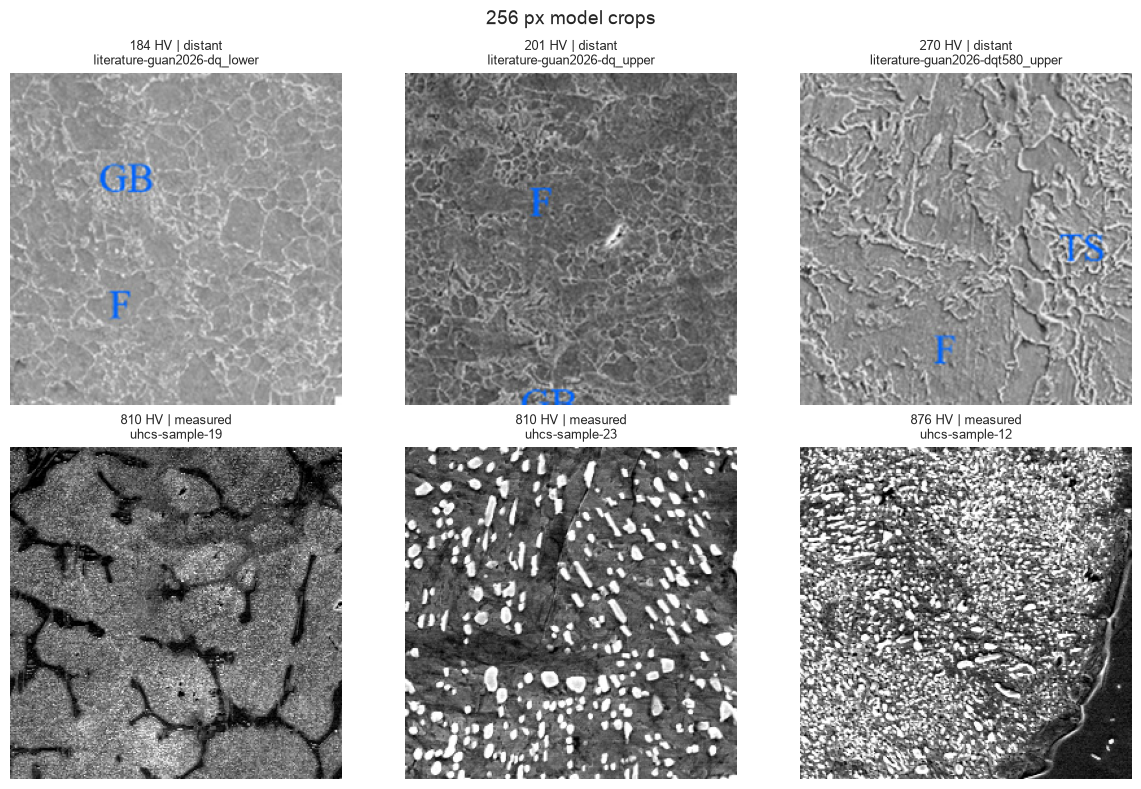

In [3]:
def centre_crop(path: Path, size: int = CROP_SIZE) -> np.ndarray:
    image = Image.open(path).convert("RGB")
    width, height = image.size
    if width < size or height < size:
        raise ValueError(f"{path} is smaller than the requested crop")
    left = (width - size) // 2
    top = (height - size) // 2
    return np.asarray(image.crop((left, top, left + size, top + size)))


representatives = (
    images.groupby("group_id", sort=False).first().reset_index()
    .sort_values("hardness_hv")
)
chosen = pd.concat(
    [representatives.head(2), representatives.iloc[[len(representatives) // 2]], representatives.tail(3)]
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for axis, (_, row) in zip(axes.flat, chosen.iterrows()):
    axis.imshow(centre_crop(row.image_path), cmap="gray")
    axis.set_title(f"{row.hardness_hv:.0f} HV | {row.property_source}\n{row.group_id}", fontsize=9)
    axis.axis("off")
fig.suptitle("256 px model crops", fontsize=14)
fig.tight_layout()
plt.show()


## 3. Run the microscopy-pretrained CNN

The backbone is NASA MicroNet's ResNet-50 checkpoint already used by this
project. The convolutional trunk is frozen and global-average-pooled to a
2048-dimensional embedding. With 17 targets, freezing the trunk is the only
defensible first experiment; full fine-tuning would mostly memorize specimens.

The cache key includes record ids, file sizes and modification times, the
encoder and crop size. Re-running the notebook does not recompute unchanged
embeddings.


In [4]:
FEATURE_CACHE = ROOT / "data" / "hardness_cnn_embeddings.npz"
transform = clf_eval_transforms(CROP_SIZE)
_encoder = None


def get_encoder():
    global _encoder
    if _encoder is None:
        _encoder = freeze(build_encoder(cfg)).to(DEVICE)
    return _encoder


def cache_key(frame: pd.DataFrame) -> str:
    fingerprint = [f"{cfg.encoder}|{cfg.encoder_weights}|{CROP_SIZE}"]
    for row in frame.itertuples():
        stat = row.image_path.stat()
        fingerprint.append(f"{row.record_id}|{stat.st_size}|{stat.st_mtime_ns}")
    return hashlib.sha256("\n".join(fingerprint).encode()).hexdigest()


@torch.inference_mode()
def embed_arrays(arrays: list[np.ndarray], batch_size: int = 8) -> np.ndarray:
    encoder = get_encoder()
    chunks = []
    for start in range(0, len(arrays), batch_size):
        tensors = [transform(image=image)["image"] for image in arrays[start:start + batch_size]]
        batch = torch.stack(tensors).to(DEVICE)
        chunks.append(encoder(batch)[-1].mean(dim=(2, 3)).cpu().numpy())
    return np.concatenate(chunks)


def embed_records(frame: pd.DataFrame, batch_size: int = 8) -> np.ndarray:
    chunks = []
    for start in range(0, len(frame), batch_size):
        batch_rows = frame.iloc[start:start + batch_size]
        arrays = [centre_crop(path) for path in batch_rows.image_path]
        chunks.append(embed_arrays(arrays, batch_size=batch_size))
        done = min(start + batch_size, len(frame))
        if done % 40 == 0 or done == len(frame):
            print(f"embedded {done}/{len(frame)}")
    return np.concatenate(chunks)


key = cache_key(images)
if FEATURE_CACHE.exists():
    blob = np.load(FEATURE_CACHE, allow_pickle=False)
    if str(blob["key"]) == key:
        cnn_features = blob["features"]
        print(f"reused {cnn_features.shape} from {FEATURE_CACHE.name}")
    else:
        print("embedding cache is stale; recomputing")
        cnn_features = embed_records(images)
else:
    cnn_features = embed_records(images)

if not FEATURE_CACHE.exists() or str(np.load(FEATURE_CACHE, allow_pickle=False)["key"]) != key:
    np.savez_compressed(FEATURE_CACHE, features=cnn_features, key=key)
    print(f"wrote {cnn_features.shape} -> {FEATURE_CACHE}")

assert cnn_features.shape == (len(images), 2048)


reused (140, 2048) from hardness_cnn_embeddings.npz


## 4. Aggregate at the physical specimen level

Embeddings are averaged within `group_id`. The evaluation block is the exact
condition when one is registered; otherwise it falls back to the physical UHCS
sample. This holds all three through-thickness locations of a Guan treatment
out together, as well as both magnifications of each location.


In [5]:
group_rows = []
group_features = []
for group_id, index in images.groupby("group_id", sort=True).groups.items():
    idx = np.asarray(list(index), dtype=int)
    row = images.loc[idx[0]]
    group_features.append(cnn_features[idx].mean(axis=0))
    group_rows.append(
        {
            "group_id": group_id,
            "adapter": row.adapter,
            "property_source": row.property_source,
            "alloy_grade": row.alloy_grade,
            "condition": row.condition,
            "evaluation_block": row.condition if pd.notna(row.condition) else group_id,
            "hardness_hv": row.hardness_hv,
            "image_count": len(idx),
            "representative_path": row.image_path,
        }
    )

groups = pd.DataFrame(group_rows)
X = np.vstack(group_features)
y = groups.hardness_hv.to_numpy(float)
blocks = groups.evaluation_block.to_numpy()

display(groups[["group_id", "image_count", "hardness_hv", "property_source", "evaluation_block"]])
print(f"CNN tensor: {X.shape}; evaluation blocks: {groups.evaluation_block.nunique()}")


,group_id,image_count,hardness_hv,property_source,evaluation_block
0,literature-guan2026-dq_lower,2,183.77,distant,condition/hot_roll_direct_quench/t900c_to_lt150c
1,literature-guan2026-dq_mid,2,210.17,distant,condition/hot_roll_direct_quench/t900c_to_lt150c
2,literature-guan2026-dq_upper,2,201.25,distant,condition/hot_roll_direct_quench/t900c_to_lt150c
3,literature-guan2026-dqt530_lower,2,242.26,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t530c_90m_wq
4,literature-guan2026-dqt530_mid,2,246.14,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t530c_90m_wq
5,literature-guan2026-dqt530_upper,2,262.82,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t530c_90m_wq
6,literature-guan2026-dqt580_lower,2,230.88,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t580c_90m_wq
7,literature-guan2026-dqt580_mid,2,253.70,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t580c_90m_wq
8,literature-guan2026-dqt580_upper,2,270.32,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t580c_90m_wq
9,literature-ren2023-oil_quenched_860c_2h,1,532.10,distant,condition/homogenize_austenitize/oil_quench/t1050c_20h_t860c_2h


CNN tensor: (17, 2048); evaluation blocks: 11


## 5. Look at the learned embedding space


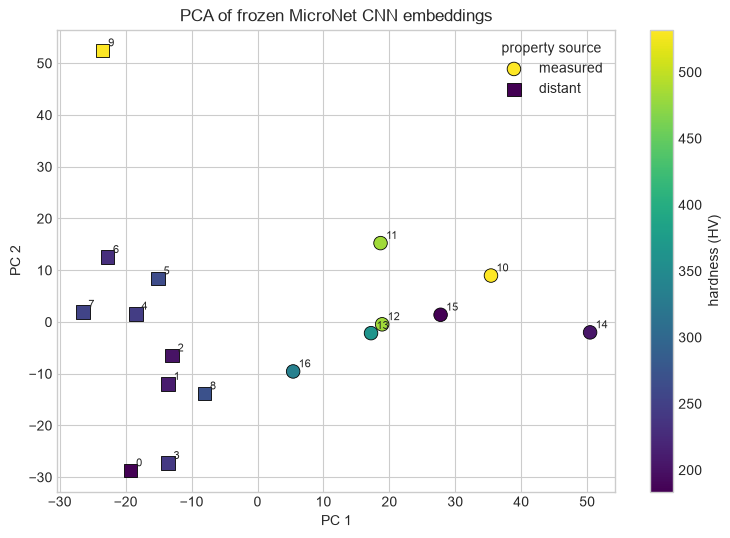

,group_id,hardness_hv,property_source
point,,,
0,literature-guan2026-dq_lower,183.77,distant
1,literature-guan2026-dq_mid,210.17,distant
2,literature-guan2026-dq_upper,201.25,distant
3,literature-guan2026-dqt530_lower,242.26,distant
4,literature-guan2026-dqt530_mid,246.14,distant
5,literature-guan2026-dqt530_upper,262.82,distant
6,literature-guan2026-dqt580_lower,230.88,distant
7,literature-guan2026-dqt580_mid,253.70,distant
8,literature-guan2026-dqt580_upper,270.32,distant


In [6]:
embedding_2d = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))

fig, axis = plt.subplots(figsize=(9, 6))
markers = {"measured": "o", "distant": "s"}
for source, marker in markers.items():
    keep = groups.property_source == source
    points = axis.scatter(
        embedding_2d[keep, 0], embedding_2d[keep, 1],
        c=y[keep], cmap="viridis", marker=marker, s=95,
        edgecolor="black", linewidth=0.6, label=source,
    )
for i, row in groups.iterrows():
    axis.annotate(str(i), embedding_2d[i], xytext=(4, 3), textcoords="offset points", fontsize=8)
axis.set(title="PCA of frozen MicroNet CNN embeddings", xlabel="PC 1", ylabel="PC 2")
axis.legend(title="property source")
fig.colorbar(points, ax=axis, label="hardness (HV)")
plt.show()

display(groups[["group_id", "hardness_hv", "property_source"]].rename_axis("point"))


## 6. Leakage-safe held-out-condition evaluation

`LeaveOneGroupOut` uses `evaluation_block`, not image id. The grade-only
baseline predicts the mean hardness of that grade in the training fold and
backs off to the global training mean for an unseen grade.

The CNN ridge model is deliberately small: standardization, at most eight PCA
components fitted inside each training fold, then ridge regression. No
hyperparameter search touches held-out targets.


In [7]:
logo = LeaveOneGroupOut()
splits = list(logo.split(X, y, blocks))
pred_mean = np.empty_like(y)
pred_grade = np.empty_like(y)
pred_ridge = np.empty_like(y)

for train_idx, test_idx in splits:
    held_out = set(blocks[test_idx])
    assert not held_out.intersection(blocks[train_idx])

    pred_mean[test_idx] = y[train_idx].mean()
    train_grades = groups.iloc[train_idx].alloy_grade.to_numpy()
    for index in test_idx:
        same_grade = train_grades == groups.iloc[index].alloy_grade
        pred_grade[index] = y[train_idx][same_grade].mean() if same_grade.any() else y[train_idx].mean()

    components = min(8, len(train_idx) - 1)
    model = make_pipeline(
        StandardScaler(),
        PCA(n_components=components, random_state=SEED),
        Ridge(alpha=10.0),
    )
    model.fit(X[train_idx], y[train_idx])
    pred_ridge[test_idx] = model.predict(X[test_idx])

print(f"{len(splits)} folds; every one holds out a complete condition or physical sample")


11 folds; every one holds out a complete condition or physical sample


## 7. Train a deep ensemble on the CNN embeddings

Each fold fits PCA on the training groups only, then trains three independently
initialized neural regressors with GELU activations, dropout and AdamW. Their
mean is the fold prediction. This is a compact deep transfer-learning model:
the large convolutional representation comes from MicroNet and the trainable
part stays small enough for the available independent targets.


In [8]:
class HardnessMLP(nn.Module):
    def __init__(self, inputs: int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(inputs, 24),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(24, 12),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(12, 1),
        )

    def forward(self, features):
        return self.layers(features).squeeze(-1)


def fit_mlp_ensemble(X_train, y_train, X_test, seeds=(11, 23, 47)):
    scaler = StandardScaler().fit(X_train)
    scaled_train = scaler.transform(X_train)
    scaled_test = scaler.transform(X_test)
    components = min(8, len(X_train) - 1)
    pca = PCA(n_components=components, random_state=SEED).fit(scaled_train)
    train_tensor = torch.tensor(pca.transform(scaled_train), dtype=torch.float32)
    test_tensor = torch.tensor(pca.transform(scaled_test), dtype=torch.float32)

    target_mean = float(y_train.mean())
    target_scale = float(y_train.std()) or 1.0
    target = torch.tensor((y_train - target_mean) / target_scale, dtype=torch.float32)

    predictions = []
    for seed in seeds:
        torch.manual_seed(seed)
        model = HardnessMLP(components)
        optimizer = torch.optim.AdamW(model.parameters(), lr=8e-3, weight_decay=5e-2)
        for _ in range(500):
            model.train()
            optimizer.zero_grad()
            loss = nn.functional.mse_loss(model(train_tensor), target)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            predictions.append(model(test_tensor).numpy() * target_scale + target_mean)
    return np.mean(predictions, axis=0)


pred_mlp = np.empty_like(y)
for fold, (train_idx, test_idx) in enumerate(splits, start=1):
    pred_mlp[test_idx] = fit_mlp_ensemble(X[train_idx], y[train_idx], X[test_idx])
    print(f"trained fold {fold:>2}/{len(splits)}; held out {blocks[test_idx][0]}")


trained fold  1/11; held out condition/austenitize/water_quench/t800c_90m


trained fold  2/11; held out condition/austenitize/water_quench/t900c_90m


trained fold  3/11; held out condition/homogenize_austenitize/oil_quench/t1050c_20h_t860c_2h


trained fold  4/11; held out condition/hot_roll_direct_quench/t900c_to_lt150c


trained fold  5/11; held out condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t530c_90m_wq


...

trained fold  7/11; held out uhcs-sample-23


trained fold  8/11; held out uhcs-sample-29


trained fold  9/11; held out uhcs-sample-3


trained fold 10/11; held out uhcs-sample-35


trained fold 11/11; held out uhcs-sample-40


## 8. Results


In [9]:
predictions = {
    "training mean": pred_mean,
    "grade-only": pred_grade,
    "CNN + ridge": pred_ridge,
    "CNN + deep ensemble": pred_mlp,
}


def score(name, prediction, mask=None):
    mask = np.ones(len(y), dtype=bool) if mask is None else np.asarray(mask)
    truth = y[mask]
    estimate = prediction[mask]
    return {
        "model": name,
        "n_groups": int(mask.sum()),
        "MAE_HV": mean_absolute_error(truth, estimate),
        "RMSE_HV": mean_squared_error(truth, estimate) ** 0.5,
        "R2": r2_score(truth, estimate),
        "Spearman_r": spearmanr(truth, estimate).statistic,
    }


overall = pd.DataFrame([score(name, pred) for name, pred in predictions.items()])
measured_mask = groups.property_source.eq("measured").to_numpy()
measured_only = pd.DataFrame(
    [score(name, pred, measured_mask) for name, pred in predictions.items()]
)

print("All 17 independent groups (measured + weak labels)")
display(overall.style.format({"MAE_HV": "{:.1f}", "RMSE_HV": "{:.1f}", "R2": "{:.3f}", "Spearman_r": "{:.3f}"}))
print("Seven directly measured UHCS groups only")
display(measured_only.style.format({"MAE_HV": "{:.1f}", "RMSE_HV": "{:.1f}", "R2": "{:.3f}", "Spearman_r": "{:.3f}"}))


All 17 independent groups (measured + weak labels)


,model,n_groups,MAE_HV,RMSE_HV,R2,Spearman_r
0,training mean,17,233.7,262.5,-0.254,-0.963
1,grade-only,17,97.0,134.6,0.670,0.587
2,CNN + ridge,17,108.4,136.9,0.659,0.803
3,CNN + deep ensemble,17,112.0,140.2,0.642,0.673


Seven directly measured UHCS groups only


,model,n_groups,MAE_HV,RMSE_HV,R2,Spearman_r
0,training mean,7,251.3,306.8,-2.186,-1.000
1,grade-only,7,174.3,200.5,-0.361,-1.000
2,CNN + ridge,7,130.4,171.2,0.007,0.198
3,CNN + deep ensemble,7,125.0,166.4,0.062,0.414


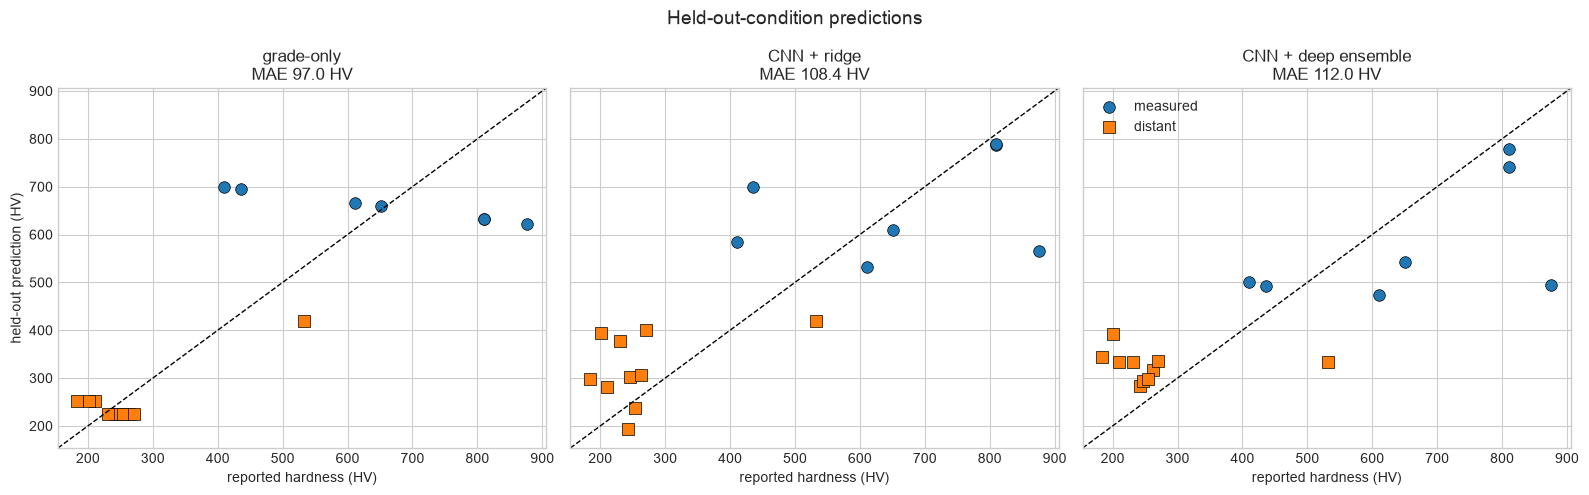

In [10]:
limits = [min(y.min(), *(p.min() for p in predictions.values())) - 30,
          max(y.max(), *(p.max() for p in predictions.values())) + 30]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for axis, name in zip(axes, ["grade-only", "CNN + ridge", "CNN + deep ensemble"]):
    pred = predictions[name]
    for source, marker, color in [("measured", "o", "tab:blue"), ("distant", "s", "tab:orange")]:
        keep = groups.property_source.eq(source).to_numpy()
        axis.scatter(y[keep], pred[keep], marker=marker, color=color, s=70,
                     edgecolor="black", linewidth=0.5, label=source)
    axis.plot(limits, limits, "k--", linewidth=1)
    mae = mean_absolute_error(y, pred)
    axis.set(title=f"{name}\nMAE {mae:.1f} HV", xlabel="reported hardness (HV)")
    axis.set_xlim(limits)
    axis.set_ylim(limits)
axes[0].set_ylabel("held-out prediction (HV)")
axes[-1].legend()
fig.suptitle("Held-out-condition predictions", fontsize=14)
fig.tight_layout()
plt.show()


In [11]:
prediction_table = groups[["group_id", "hardness_hv", "property_source", "evaluation_block"]].copy()
for name, pred in predictions.items():
    prediction_table[name] = pred
    prediction_table[f"abs error: {name}"] = np.abs(pred - y)

display(
    prediction_table.sort_values("abs error: CNN + ridge", ascending=False)
    .style.format({column: "{:.1f}" for column in prediction_table if column not in {
        "group_id", "property_source", "evaluation_block"
    }})
)


,group_id,hardness_hv,property_source,evaluation_block,training mean,abs error: training mean,grade-only,abs error: grade-only,CNN + ridge,abs error: CNN + ridge,CNN + deep ensemble,abs error: CNN + deep ensemble
10,uhcs-sample-12,876.0,measured,condition/austenitize/water_quench/t800c_90m,397.6,478.4,621.3,254.7,566.0,310.0,493.6,382.4
14,uhcs-sample-3,436.0,measured,uhcs-sample-3,425.1,10.9,694.7,258.7,699.8,263.8,492.8,56.8
2,literature-guan2026-dq_upper,201.2,distant,condition/hot_roll_direct_quench/t900c_to_lt150c,474.4,273.2,251.0,49.8,393.2,192.0,392.5,191.3
15,uhcs-sample-35,410.0,measured,uhcs-sample-35,426.7,16.7,699.0,289.0,585.4,175.4,500.2,90.2
6,literature-guan2026-dqt580_lower,230.9,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t580c_90m_wq,463.0,232.2,224.4,6.5,376.9,146.1,333.4,102.5
8,literature-guan2026-dqt580_upper,270.3,distant,condition/hot_roll_direct_quench/t900c_to_lt150c_temper_t580c_90m_wq,463.0,192.7,224.4,45.9,399.4,129.1,336.5,66.1
0,literature-guan2026-dq_lower,183.8,distant,condition/hot_roll_direct_quench/t900c_to_lt150c,474.4,290.7,251.0,67.2,298.6,114.9,344.3,160.5
9,literature-ren2023-oil_quenched_860c_2h,532.1,distant,condition/homogenize_austenitize/oil_quench/t1050c_20h_t860c_2h,419.1,113.0,419.1,113.0,419.6,112.5,334.1,198.0
16,uhcs-sample-40,611.0,measured,uhcs-sample-40,414.2,196.8,665.5,54.5,533.1,77.9,473.6,137.4
1,literature-guan2026-dq_mid,210.2,distant,condition/hot_roll_direct_quench/t900c_to_lt150c,474.4,264.3,251.0,40.8,281.6,71.4,333.3,123.1


## 9. CNN nearest-neighbour retrieval

This asks a different question: which held-out material state looks most
similar in the learned microscopy representation? Neighbours from the same
evaluation block are excluded so the answer cannot be the other magnification
or through-thickness location of the same treatment.


In [12]:
unit = X / np.linalg.norm(X, axis=1, keepdims=True)
similarity = unit @ unit.T
neighbours = []
for i, row in groups.iterrows():
    candidates = np.flatnonzero(groups.evaluation_block.to_numpy() != row.evaluation_block)
    nearest = candidates[np.argmax(similarity[i, candidates])]
    neighbours.append(
        {
            "query": row.group_id,
            "query_HV": row.hardness_hv,
            "nearest_other_condition": groups.iloc[nearest].group_id,
            "neighbour_HV": groups.iloc[nearest].hardness_hv,
            "absolute_HV_gap": abs(row.hardness_hv - groups.iloc[nearest].hardness_hv),
            "cosine_similarity": similarity[i, nearest],
        }
    )

neighbour_table = pd.DataFrame(neighbours).sort_values("absolute_HV_gap")
display(neighbour_table.style.format({
    "query_HV": "{:.1f}", "neighbour_HV": "{:.1f}",
    "absolute_HV_gap": "{:.1f}", "cosine_similarity": "{:.3f}",
}))


,query,query_HV,nearest_other_condition,neighbour_HV,absolute_HV_gap,cosine_similarity
5,literature-guan2026-dqt530_upper,262.8,literature-guan2026-dqt580_mid,253.7,9.1,0.936
4,literature-guan2026-dqt530_mid,246.1,literature-guan2026-dqt580_lower,230.9,15.3,0.945
6,literature-guan2026-dqt580_lower,230.9,literature-guan2026-dqt530_mid,246.1,15.3,0.945
14,uhcs-sample-3,436.0,uhcs-sample-35,410.0,26.0,0.906
3,literature-guan2026-dqt530_lower,242.3,literature-guan2026-dqt580_upper,270.3,28.1,0.930
16,uhcs-sample-40,611.0,uhcs-sample-29,651.0,40.0,0.937
1,literature-guan2026-dq_mid,210.2,literature-guan2026-dqt580_mid,253.7,43.5,0.939
7,literature-guan2026-dqt580_mid,253.7,literature-guan2026-dq_mid,210.2,43.5,0.939
0,literature-guan2026-dq_lower,183.8,literature-guan2026-dqt530_lower,242.3,58.5,0.903
8,literature-guan2026-dqt580_upper,270.3,literature-guan2026-dq_mid,210.2,60.2,0.934


## 10. Occlusion sensitivity

The final ridge model is fitted on all 17 groups for a qualitative diagnostic.
One measured micrograph is divided into a 4 by 4 grid. Each tile is replaced
with the crop mean and passed through the CNN again. The heatmap shows how much
that occlusion changes the predicted hardness. This is not causal phase
attribution, but it reveals whether the regressor depends on localized texture
or on one suspicious border region.


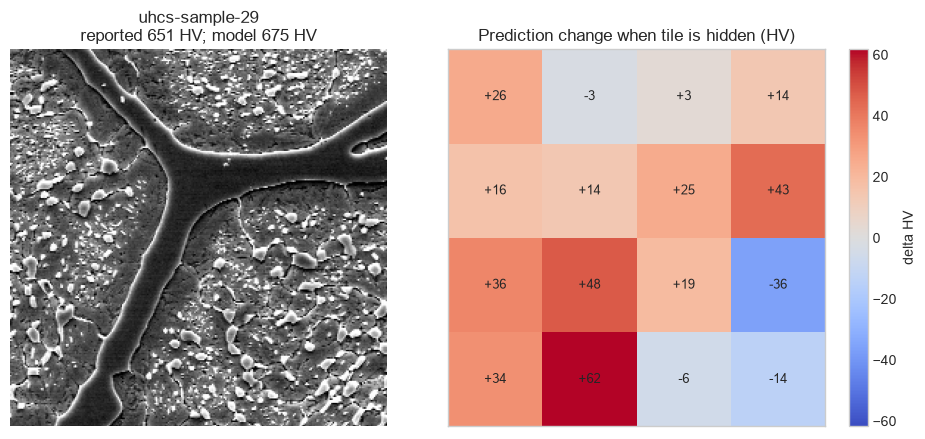

In [13]:
final_model = make_pipeline(
    StandardScaler(),
    PCA(n_components=min(8, len(groups) - 1), random_state=SEED),
    Ridge(alpha=10.0),
).fit(X, y)

target_group = groups.loc[groups.property_source.eq("measured")].iloc[
    np.argsort(groups.loc[groups.property_source.eq("measured"), "hardness_hv"].to_numpy())[3]
]
target_record = images.loc[images.group_id.eq(target_group.group_id)].iloc[0]
crop = centre_crop(target_record.image_path)

grid = 4
tile = CROP_SIZE // grid
occluded = [crop]
fill = crop.mean(axis=(0, 1)).astype(np.uint8)
for row in range(grid):
    for column in range(grid):
        changed = crop.copy()
        changed[row * tile:(row + 1) * tile, column * tile:(column + 1) * tile] = fill
        occluded.append(changed)

occlusion_features = embed_arrays(occluded)
occlusion_predictions = final_model.predict(occlusion_features)
base_prediction = occlusion_predictions[0]
delta = (occlusion_predictions[1:] - base_prediction).reshape(grid, grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(crop)
axes[0].set_title(f"{target_group.group_id}\nreported {target_group.hardness_hv:.0f} HV; model {base_prediction:.0f} HV")
axes[0].axis("off")
bound = max(abs(delta.min()), abs(delta.max()), 1.0)
heat = axes[1].imshow(delta, cmap="coolwarm", vmin=-bound, vmax=bound)
for row in range(grid):
    for column in range(grid):
        axes[1].text(column, row, f"{delta[row, column]:+.0f}", ha="center", va="center", fontsize=9)
axes[1].set_title("Prediction change when tile is hidden (HV)")
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(heat, ax=axes[1], label="delta HV")
fig.tight_layout()
plt.show()


## 11. Read the result honestly

The important comparison is not whether a neural network can fit 17 numbers.
It is whether image-based models beat the grade-only baseline when complete
conditions are held out, and whether that survives on the seven directly
measured UHCS targets.

If the CNN models do not win, that is still useful: the current corpus is
letting the network recognize sources or grades more easily than it can infer
hardness from morphology. The next defensible gains would come from more
independent treatment groups, a scale-aware multi-crop representation and
masking every published annotation. Full ResNet fine-tuning should wait until
there are substantially more than 17 independent targets.


In [14]:
best_overall = overall.sort_values("MAE_HV").iloc[0]
best_measured = measured_only.sort_values("MAE_HV").iloc[0]
ridge_mae = float(overall.loc[overall.model.eq("CNN + ridge"), "MAE_HV"].iloc[0])
grade_mae = float(overall.loc[overall.model.eq("grade-only"), "MAE_HV"].iloc[0])
ridge_rank = float(overall.loc[overall.model.eq("CNN + ridge"), "Spearman_r"].iloc[0])
grade_rank = float(overall.loc[overall.model.eq("grade-only"), "Spearman_r"].iloc[0])
deep_measured_mae = float(
    measured_only.loc[measured_only.model.eq("CNN + deep ensemble"), "MAE_HV"].iloc[0]
)
grade_measured_mae = float(
    measured_only.loc[measured_only.model.eq("grade-only"), "MAE_HV"].iloc[0]
)

print(f"best overall held-out MAE:       {best_overall.model} ({best_overall.MAE_HV:.1f} HV)")
print(f"best measured-UHCS-only MAE:     {best_measured.model} ({best_measured.MAE_HV:.1f} HV)")
print(f"CNN ridge minus grade baseline:  {ridge_mae - grade_mae:+.1f} HV")
print(f"CNN rank lift over grade:        {ridge_rank - grade_rank:+.3f} Spearman r")
print(f"deep measured-MAE improvement:   {grade_measured_mae - deep_measured_mae:+.1f} HV")
print()
if ridge_mae < grade_mae:
    print("The frozen CNN adds signal beyond grade identity on this split.")
else:
    print("The CNN does not yet beat grade recognition under the leakage-safe split.")
print("Treat the measured-only table as the calibration anchor; distant labels are training evidence, not ground truth.")


best overall held-out MAE:       grade-only (97.0 HV)
best measured-UHCS-only MAE:     CNN + deep ensemble (125.0 HV)
CNN ridge minus grade baseline:  +11.4 HV
CNN rank lift over grade:        +0.216 Spearman r
deep measured-MAE improvement:   +49.3 HV

The CNN does not yet beat grade recognition under the leakage-safe split.
Treat the measured-only table as the calibration anchor; distant labels are training evidence, not ground truth.


## Reproduce

From the repository root:

    uv run --with jupyter --with matplotlib jupyter nbconvert \
      --to notebook --execute --inplace \
      --ExecutePreprocessor.timeout=900 \
      notebooks/distant_supervision_walkthrough.ipynb

The CNN embedding cache is written under `data/` and is intentionally ignored
by git. Delete `data/hardness_cnn_embeddings.npz` to force a fresh forward
pass.
